# Lab 05: Mixed integer linear programming (MILP)

Using PULP Library for Python
https://coin-or.github.io/pulp/index.html


### 3.1 Example 1:  Production Planning (PuLP) 

A company produces two products, A and B.  Each unit of A requires 2 hours of labor and 1 unit of raw material.  Each unit of B requires 3 hours of labor and 2 units of raw material.  The company has 12 hours of labor and 7 units of raw material available.  The profit per unit of A is $3, and the profit per unit of B is $5.  How many units of each product should the company produce to maximize profit? 

Omejitve problema smo spremenili

In [4]:
!pip install pulp
from pulp import *

# Create the LP problem
prob = LpProblem("Production_Planning", LpMaximize)

# Define decision variables
A = LpVariable("A", lowBound=0, cat='Integer')  # Number of units of A
B = LpVariable("B", lowBound=0, cat='Integer')  # Number of units of B

# Define the objective function
prob += 6 * A + 10 * B, "Total Profit"

# Define the constraints
prob += 2 * A + 3 * B <= 40, "Labor Constraint"
prob += A + 2 * B <= 30, "Raw Material Constraint"

# Solve the problem
prob.solve()

# Print the results
print("Status:", LpStatus[prob.status])
print("Units of A:", A.varValue)
print("Units of B:", B.varValue)
print("Total Profit:", value(prob.objective))

Status: Optimal
Units of A: 2.0
Units of B: 12.0
Total Profit: 132.0



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 3.2: Shortest Path in Network

In [5]:
from pulp import *

# Create the LP problem
prob = LpProblem("Routing_Problem", LpMinimize)

# Define decision variables
ab = LpVariable("ab", lowBound=0, cat='Integer')  
ac = LpVariable("ac", lowBound=0, cat='Integer')  
ad = LpVariable("ad", lowBound=0, cat='Integer')
bh = LpVariable("bh", lowBound=0, cat='Integer')
cb = LpVariable("cb", lowBound=0, cat='Integer')
cd = LpVariable("cd", lowBound=0, cat='Integer')
cf = LpVariable("cf", lowBound=0, cat='Integer')
di = LpVariable("di", lowBound=0, cat='Integer')
de = LpVariable("de", lowBound=0, cat='Integer')
ec = LpVariable("ec", lowBound=0, cat='Integer')
ef = LpVariable("ef", lowBound=0, cat='Integer')
eg = LpVariable("eg", lowBound=0, cat='Integer')
ei = LpVariable("ei", lowBound=0, cat='Integer')
fb = LpVariable("fb", lowBound=0, cat='Integer')
fh = LpVariable("fh", lowBound=0, cat='Integer')
gf = LpVariable("gf", lowBound=0, cat='Integer')
gh = LpVariable("gh", lowBound=0, cat='Integer')
gi = LpVariable("gi", lowBound=0, cat='Integer')
ih = LpVariable("ih", lowBound=0, cat='Integer')


# Define the objective function
prob += 15*ab + 13*ac + 5*ad + 11*bh + 2*cb + 18*cd + 6*cf + 4*de +99*di +3*ec +1*ef +9*eg +14*ei +8*fb +17*fh +16*gf +7*gh +10*gi +12*ih, "Total Cost"

# Define the constraints
# Source and target nodes
prob += +ab +ac +ad == 1, "Source A traffic"
prob += +fh +gh +ih +bh == 1, "Target H traffic"

# Intermediate nodes
prob += -ab -cb -fb + bh == 0, "Node B traffic"
prob += -ac -ec +cd +cf + cb == 0, "Node C traffic"
prob += -ad -cd +de +di == 0, "Node D traffic"
prob += -de +ef +eg +ec +ei == 0, "Node E traffic"
prob += -cf -ef -gf +fb +fh == 0, "Node F traffic"
prob += -eg +gf +gh +gi == 0, "Node G traffic"
prob += -di -ei -gi + ih == 0, "Node I traffic"

# Solve the problem
prob.solve()

# Print the results
print("Status:", LpStatus[prob.status])

print("OBJECTIVE: Total Cost:", value(prob.objective))

print("SOLUTION:    ")

# Print variables
for v in prob.variables():
    print(v.name, "=", v.varValue)

print("Problem : ", prob)



Status: Optimal
OBJECTIVE: Total Cost: 25.0
SOLUTION:    
ab = 0.0
ac = 0.0
ad = 1.0
bh = 0.0
cb = 0.0
cd = 0.0
cf = 0.0
de = 1.0
di = 0.0
ec = 0.0
ef = 0.0
eg = 1.0
ei = 0.0
fb = 0.0
fh = 0.0
gf = 0.0
gh = 1.0
gi = 0.0
ih = 0.0
Problem :  Routing_Problem:
MINIMIZE
15*ab + 13*ac + 5*ad + 11*bh + 2*cb + 18*cd + 6*cf + 4*de + 99*di + 3*ec + 1*ef + 9*eg + 14*ei + 8*fb + 17*fh + 16*gf + 7*gh + 10*gi + 12*ih + 0
SUBJECT TO
Source_A_traffic: ab + ac + ad = 1

Target_H_traffic: bh + fh + gh + ih = 1

Node_B_traffic: - ab + bh - cb - fb = 0

Node_C_traffic: - ac + cb + cd + cf - ec = 0

Node_D_traffic: - ad - cd + de + di = 0

Node_E_traffic: - de + ec + ef + eg + ei = 0

Node_F_traffic: - cf - ef + fb + fh - gf = 0

Node_G_traffic: - eg + gf + gh + gi = 0

Node_I_traffic: - di - ei - gi + ih = 0

VARIABLES
0 <= ab Integer
0 <= ac Integer
0 <= ad Integer
0 <= bh Integer
0 <= cb Integer
0 <= cd Integer
0 <= cf Integer
0 <= de Integer
0 <= di Integer
0 <= ec Integer
0 <= ef Integer
0 <= eg Integ

### 3.3 Rešitev Problema 1

Zapiši in reši Problem 1 z uporabo primera 2.

In [11]:
# Create the LP problem
prob = LpProblem("Routing_Problem", LpMinimize)

# Define decision variables
ab = LpVariable("ab", lowBound=0, cat='Integer')  
ac = LpVariable("ac", lowBound=0, cat='Integer')  
ad = LpVariable("ad", lowBound=0, cat='Integer')
bh = LpVariable("bh", lowBound=0, cat='Integer')
cb = LpVariable("cb", lowBound=0, cat='Integer')
cd = LpVariable("cd", lowBound=0, cat='Integer')
cf = LpVariable("cf", lowBound=0, cat='Integer')
di = LpVariable("di", lowBound=0, cat='Integer')
de = LpVariable("de", lowBound=0, cat='Integer')
ec = LpVariable("ec", lowBound=0, cat='Integer')
ef = LpVariable("ef", lowBound=0, cat='Integer')
eg = LpVariable("eg", lowBound=0, cat='Integer')
ei = LpVariable("ei", lowBound=0, cat='Integer')
fb = LpVariable("fb", lowBound=0, cat='Integer')
fh = LpVariable("fh", lowBound=0, cat='Integer')
gf = LpVariable("gf", lowBound=0, cat='Integer')
gh = LpVariable("gh", lowBound=0, cat='Integer')
gi = LpVariable("gi", lowBound=0, cat='Integer')
ih = LpVariable("ih", lowBound=0, cat='Integer')


# Define the objective function
prob += 42*ab + 7*ac + 18*ad + 5*bh + 31*cb + 9*cd + 30*cf + 6*de + 16*di + 12*ec +15*ef +8*eg +10*ei + 2*fb + 9*fh +4*gf +23*gh +10*gi +22*ih, "Total Cost"

# Define the constraints
# Source and target nodes
prob += +ab +ac +ad == 5, "Source A traffic"
prob += +fh +gh +ih +bh == 5, "Target H traffic"

# Intermediate nodes
prob += -ab -cb -fb + bh == 0, "Node B traffic"
prob += +ab +cb +fb <= 2, "Omejitev B"
prob += -ac -ec +cd +cf + cb == 0, "Node C traffic"
prob += +ac +ec  <= 4, "Omejitev C"
prob += -ad -cd +de +di == 0, "Node D traffic"
prob += +ad +cd <= 2, "Omejitev D"
prob += -de +ef +eg +ec +ei == 0, "Node E traffic"
prob += +de <= 3,  "Node E"
prob += -cf -ef -gf +fb +fh == 0, "Node F traffic"
prob += +cf +ef +gf <= 6
prob += -eg +gf +gh +gi == 0, "Node G traffic"
prob += +eg <= 5
prob += -di -ei -gi + ih == 0, "Node I traffic"
prob += +di +ei +gi <= 2
# Solve the problem
prob.solve()

# Print the results
print("Status:", LpStatus[prob.status])

print("OBJECTIVE: Total Cost:", value(prob.objective))

print("SOLUTION:    ")

# Print variables
for v in prob.variables():
    print(v.name, "=", v.varValue)

print("Problem : ", prob)


Status: Optimal
OBJECTIVE: Total Cost: 220.0
SOLUTION:    
ab = 0.0
ac = 4.0
ad = 1.0
bh = 2.0
cb = 2.0
cd = 1.0
cf = 1.0
de = 2.0
di = 0.0
ec = 0.0
ef = 0.0
eg = 2.0
ei = 0.0
fb = 0.0
fh = 3.0
gf = 2.0
gh = 0.0
gi = 0.0
ih = 0.0
Problem :  Routing_Problem:
MINIMIZE
42*ab + 7*ac + 18*ad + 5*bh + 31*cb + 9*cd + 30*cf + 6*de + 16*di + 12*ec + 15*ef + 8*eg + 10*ei + 2*fb + 9*fh + 4*gf + 23*gh + 10*gi + 22*ih + 0
SUBJECT TO
Source_A_traffic: ab + ac + ad = 5

Target_H_traffic: bh + fh + gh + ih = 5

Node_B_traffic: - ab + bh - cb - fb = 0

Omejitev_B: ab + cb + fb <= 2

Node_C_traffic: - ac + cb + cd + cf - ec = 0

Omejitev_C: ac + ec <= 4

Node_D_traffic: - ad - cd + de + di = 0

Omejitev_D: ad + cd <= 2

Node_E_traffic: - de + ec + ef + eg + ei = 0

Node_E: de <= 3

Node_F_traffic: - cf - ef + fb + fh - gf = 0

_C1: cf + ef + gf <= 6

Node_G_traffic: - eg + gf + gh + gi = 0

_C2: eg <= 5

Node_I_traffic: - di - ei - gi + ih = 0

_C3: di + ei + gi <= 2

VARIABLES
0 <= ab Integer
0 <= ac I

In [15]:
# Create the LP problem
prob = LpProblem("Routing_Problem", LpMinimize)

# Define decision variables
ab = LpVariable("ab", lowBound=0, cat='Integer')  
ac = LpVariable("ac", lowBound=0, cat='Integer')  
ad = LpVariable("ad", lowBound=0, cat='Integer')
bh = LpVariable("bh", lowBound=0, cat='Integer')
cb = LpVariable("cb", lowBound=0, cat='Integer')
cd = LpVariable("cd", lowBound=0, cat='Integer')
cf = LpVariable("cf", lowBound=0, cat='Integer')
di = LpVariable("di", lowBound=0, cat='Integer')
de = LpVariable("de", lowBound=0, cat='Integer')
ec = LpVariable("ec", lowBound=0, cat='Integer')
ef = LpVariable("ef", lowBound=0, cat='Integer')
eg = LpVariable("eg", lowBound=0, cat='Integer')
ei = LpVariable("ei", lowBound=0, cat='Integer')
fb = LpVariable("fb", lowBound=0, cat='Integer')
fh = LpVariable("fh", lowBound=0, cat='Integer')
gf = LpVariable("gf", lowBound=0, cat='Integer')
gh = LpVariable("gh", lowBound=0, cat='Integer')
gi = LpVariable("gi", lowBound=0, cat='Integer')
ih = LpVariable("ih", lowBound=0, cat='Integer')


# Define the objective function
prob += 42*ab + 7*ac + 18*ad + 5*bh + 31*cb + 9*cd + 30*cf + 6*de + 16*di + 12*ec +15*ef +8*eg +10*ei + 2*fb + 9*fh +4*gf +23*gh +10*gi +22*ih, "Total Cost"

# Define the constraints
# Source and target nodes
prob += +ab +ac +ad == 10, "Source A traffic"
prob += +fh +gh +ih +bh == 10, "Target H traffic"

# Intermediate nodes
prob += -ab -cb -fb + bh == 0, "Node B traffic"
prob += +ab +cb +fb <=15, "Omejitev B"
prob += -ac -ec +cd +cf + cb == 0, "Node C traffic"
prob += +ac +ec  <= 14, "Omejitev C"
prob += -ad -cd +de +di == 0, "Node D traffic"
prob += +ad +cd <= 15, "Omejitev D"
prob += -de +ef +eg +ec +ei == 0, "Node E traffic"
prob += +de <= 15,  "Node E"
prob += -cf -ef -gf +fb +fh == 0, "Node F traffic"
prob += +cf +ef +gf <= 10
prob += -eg +gf +gh +gi == 0, "Node G traffic"
prob += +eg <= 51
prob += -di -ei -gi + ih == 0, "Node I traffic"
prob += +di +ei +gi <= 21
# Solve the problem
prob.solve()

# Print the results
print("Status:", LpStatus[prob.status])

print("OBJECTIVE: Total Cost:", value(prob.objective))

print("SOLUTION:    ")

# Print variables
for v in prob.variables():
    print(v.name, "=", v.varValue)

print("Problem : ", prob)

Status: Optimal
OBJECTIVE: Total Cost: 410.0
SOLUTION:    
ab = 0.0
ac = 10.0
ad = 0.0
bh = 10.0
cb = 0.0
cd = 10.0
cf = 0.0
de = 10.0
di = 0.0
ec = 0.0
ef = 0.0
eg = 10.0
ei = 0.0
fb = 10.0
fh = 0.0
gf = 10.0
gh = 0.0
gi = 0.0
ih = 0.0
Problem :  Routing_Problem:
MINIMIZE
42*ab + 7*ac + 18*ad + 5*bh + 31*cb + 9*cd + 30*cf + 6*de + 16*di + 12*ec + 15*ef + 8*eg + 10*ei + 2*fb + 9*fh + 4*gf + 23*gh + 10*gi + 22*ih + 0
SUBJECT TO
Source_A_traffic: ab + ac + ad = 10

Target_H_traffic: bh + fh + gh + ih = 10

Node_B_traffic: - ab + bh - cb - fb = 0

Omejitev_B: ab + cb + fb <= 15

Node_C_traffic: - ac + cb + cd + cf - ec = 0

Omejitev_C: ac + ec <= 14

Node_D_traffic: - ad - cd + de + di = 0

Omejitev_D: ad + cd <= 15

Node_E_traffic: - de + ec + ef + eg + ei = 0

Node_E: de <= 15

Node_F_traffic: - cf - ef + fb + fh - gf = 0

_C1: cf + ef + gf <= 10

Node_G_traffic: - eg + gf + gh + gi = 0

_C2: eg <= 51

Node_I_traffic: - di - ei - gi + ih = 0

_C3: di + ei + gi <= 21

VARIABLES
0 <= ab I

## 4. Problem 2: Optimizing network infrastructure

In [ ]:
# 4.1 Variant A

# Problem Data
Servers = [1, 2, 3, 4]
ServerCosts = {1: 2000, 2: 3000, 3: 2000, 4: 4000}
ServerBandwidth = {1: 3, 2: 2, 3: 2, 4: 4}

Clients = [1, 2, 3]
ClientRequests = {1: 2.5, 2: 2.5, 3: 6}
ClientCostTb = 3000

# Links server-client
Links = [(1,1),(1,2),(1,3),(2,1),(2,2),(2,3), (3,1), (3,2), (3,3),  (4,1), (4,2), (4,3)]

# Create the LP problem
prob = LpProblem("Bandwidth Allocation", LpMaximize)

# Decision Variables: 
bandwidth = LpVariable.dicts("B", Links, lowBound=0, cat='Continuous')
print(bandwidth)
print(prob.variables())

# Objective Function
prob += lpSum([ClientCostTb * bandwidth[link] for link in Links]), "Total Profit"
print("Objective function:", prob.objective)

# Constraints
# 1. Server Bandwidth Constraints
for s in Servers:
    prob += lpSum([bandwidth[(s, c)] for c in Clients]) <= ServerBandwidth[s], f"ServerBandwidth_{s}"

# 2. Client Request Constraints
for c in Clients:
    prob += lpSum([bandwidth[(s, c)] for s in Servers]) == ClientRequests[c], f"ClientRequest_{c}"
print(prob.constraints)

# Solve the problem
prob.solve()

# Print the results
print("\nOPTIMAL SOLUTION Status:", LpStatus[prob.status])
if prob.status == 1:
    print("     Optimal Solution Found")
else:
    print("     !!!!!!!!!!   Error: No Optimal Solution Found")

print("Total Profit:", value(prob.objective))

print("\nDecision Variables:")
for s in Servers:
    for c in Clients:
        print(f"Allocate bandwidth server {s} to client {c}: {bandwidth[(s, c)].varValue}")

        

{(1, 1): B_(1,_1), (1, 2): B_(1,_2), (1, 3): B_(1,_3), (2, 1): B_(2,_1), (2, 2): B_(2,_2), (2, 3): B_(2,_3), (3, 1): B_(3,_1), (3, 2): B_(3,_2), (3, 3): B_(3,_3), (4, 1): B_(4,_1), (4, 2): B_(4,_2), (4, 3): B_(4,_3)}
[]
Objective function: 3000*B_(1,_1) + 3000*B_(1,_2) + 3000*B_(1,_3) + 3000*B_(2,_1) + 3000*B_(2,_2) + 3000*B_(2,_3) + 3000*B_(3,_1) + 3000*B_(3,_2) + 3000*B_(3,_3) + 3000*B_(4,_1) + 3000*B_(4,_2) + 3000*B_(4,_3)
OrderedDict({'ServerBandwidth_1': 1*B_(1,_1) + 1*B_(1,_2) + 1*B_(1,_3) + -3.0 <= 0, 'ServerBandwidth_2': 1*B_(2,_1) + 1*B_(2,_2) + 1*B_(2,_3) + -2.0 <= 0, 'ServerBandwidth_3': 1*B_(3,_1) + 1*B_(3,_2) + 1*B_(3,_3) + -2.0 <= 0, 'ServerBandwidth_4': 1*B_(4,_1) + 1*B_(4,_2) + 1*B_(4,_3) + -4.0 <= 0, 'ClientRequest_1': 1*B_(1,_1) + 1*B_(2,_1) + 1*B_(3,_1) + 1*B_(4,_1) + -2.5 = 0, 'ClientRequest_2': 1*B_(1,_2) + 1*B_(2,_2) + 1*B_(3,_2) + 1*B_(4,_2) + -2.5 = 0, 'ClientRequest_3': 1*B_(1,_3) + 1*B_(2,_3) + 1*B_(3,_3) + 1*B_(4,_3) + -6.0 = 0})

OPTIMAL SOLUTION Status: Opt

c:\Python312\Lib\site-packages\pulp\pulp.py:1424: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


In [ ]:
# 4.2 Variant B

In [26]:
# 4.3 Variant C
from pulp import *

# Problem Data
Servers = [1, 2, 3, 4]
ServerCosts = {1: 2000, 2: 3000, 3: 2000, 4: 4000}
ServerBandwidth = {1: 3, 2: 2, 3: 2, 4: 4}

Clients = [1, 2, 3]
ClientRequests = {1: 2.5, 2: 2, 3: 3}
ClientCostTb = 3000

# Links server-client
Links = [(1,1),(1,2),(1,3),(2,1),(2,2),(2,3), (3,1), (3,2), (3,3),  (4,1), (4,2), (4,3)]


# Create the LP problem
prob = LpProblem("Bandwidth Allocation", LpMaximize)

# Decision Variables: 
bandwidth = LpVariable.dicts("B", Links, lowBound=0, cat='Continuous')
print(bandwidth)
print(prob.variables())

lease = LpVariable.dicts("L", Servers, lowBound=0, cat='Binary')
print(lease)

# Objective Function
prob += lpSum([ClientCostTb * bandwidth[link] for link in Links]) - lpSum([ServerCosts[s]*lease[s] for s in Servers]) , "Total Profit"


print("Objective function:", prob.objective)

# Constraints
# 1. Server Bandwidth Constraints
for s in Servers:
    prob += lpSum([bandwidth[(s, c)] for c in Clients]) <= ServerBandwidth[s]*lease[s], f"ServerBandwidth_{s}"

# 2. Client Request Constraints
for c in Clients:
    prob += lpSum([bandwidth[(s, c)] for s in Servers]) == ClientRequests[c], f"ClientRequest_{c}"
print(prob.constraints)

# Solve the problem
prob.solve()

# Print the results
print("\nOPTIMAL SOLUTION Status:", LpStatus[prob.status])
if prob.status == 1:
    print("     Optimal Solution Found")
else:
    print("     !!!!!!!!!!   Error: No Optimal Solution Found")

print("Total Profit:", value(prob.objective))

for s in Servers:
    print(lease[s].varValue)

print("\nDecision Variables:")
for s in Servers:
    for c in Clients:
        print(f"Allocate bandwidth server {s} to client {c}: {bandwidth[(s, c)].varValue}")

{(1, 1): B_(1,_1), (1, 2): B_(1,_2), (1, 3): B_(1,_3), (2, 1): B_(2,_1), (2, 2): B_(2,_2), (2, 3): B_(2,_3), (3, 1): B_(3,_1), (3, 2): B_(3,_2), (3, 3): B_(3,_3), (4, 1): B_(4,_1), (4, 2): B_(4,_2), (4, 3): B_(4,_3)}
[]
{1: L_1, 2: L_2, 3: L_3, 4: L_4}
Objective function: 3000*B_(1,_1) + 3000*B_(1,_2) + 3000*B_(1,_3) + 3000*B_(2,_1) + 3000*B_(2,_2) + 3000*B_(2,_3) + 3000*B_(3,_1) + 3000*B_(3,_2) + 3000*B_(3,_3) + 3000*B_(4,_1) + 3000*B_(4,_2) + 3000*B_(4,_3) - 2000*L_1 - 3000*L_2 - 2000*L_3 - 4000*L_4
OrderedDict({'ServerBandwidth_1': 1*B_(1,_1) + 1*B_(1,_2) + 1*B_(1,_3) + -3*L_1 + 0.0 <= 0, 'ServerBandwidth_2': 1*B_(2,_1) + 1*B_(2,_2) + 1*B_(2,_3) + -2*L_2 + 0.0 <= 0, 'ServerBandwidth_3': 1*B_(3,_1) + 1*B_(3,_2) + 1*B_(3,_3) + -2*L_3 + 0.0 <= 0, 'ServerBandwidth_4': 1*B_(4,_1) + 1*B_(4,_2) + 1*B_(4,_3) + -4*L_4 + 0.0 <= 0, 'ClientRequest_1': 1*B_(1,_1) + 1*B_(2,_1) + 1*B_(3,_1) + 1*B_(4,_1) + -2.5 = 0, 'ClientRequest_2': 1*B_(1,_2) + 1*B_(2,_2) + 1*B_(3,_2) + 1*B_(4,_2) + -2.0 = 0, 'C

In [11]:
# 4.4 Variant D

# Problem Data
Servers = [1, 2, 3, 4]
ServerCosts = {1: 2000, 2: 3000, 3: 2000, 4: 4000}
ServerBandwidth = {1: 3, 2: 2, 3: 2, 4: 4}

# Spremeni
#Clients = [1, 2, 3]
#ClientRequests = {1: 2.5, 2: 2, 3: 3}
#ClientRate = {1: 2000, 2: 3000, 3: 2500}
# Link server-client
# Links = [(1,1), (1,2), (1,3), (2,1), (2,2), (2,3), (3,1), (3,2), (3,3), (4,1), (4,2), (4,3)]


### 5 Dynamic routing
Dodatna naloga

['Ljubljana', 'Celje', 'Trbovlje', 'Maribor', 'Ptuj', 'Rogaska Slatina', 'Murska Sobota', 'Krsko', 'Novo mesto', 'Kocevje', 'Postojna', 'Koper', 'Portoroz', 'Kranj', 'Jesenice', 'Nova Gorica', 'Velenje', 'Dravograd']
[('Ljubljana', 'Maribor'), ('Ljubljana', 'Koper'), ('Ljubljana', 'Nova Gorica'), ('Ljubljana', 'Kranj'), ('Ljubljana', 'Celje'), ('Ljubljana', 'Novo mesto'), ('Ljubljana', 'Portoroz'), ('Ljubljana', 'Postojna'), ('Ljubljana', 'Trbovlje'), ('Ljubljana', 'Kocevje'), ('Celje', 'Maribor'), ('Celje', 'Velenje'), ('Celje', 'Trbovlje'), ('Maribor', 'Ptuj'), ('Maribor', 'Dravograd'), ('Maribor', 'Murska Sobota'), ('Ptuj', 'Rogaska Slatina'), ('Ptuj', 'Murska Sobota'), ('Rogaska Slatina', 'Novo mesto'), ('Rogaska Slatina', 'Krsko'), ('Krsko', 'Novo mesto'), ('Novo mesto', 'Kocevje'), ('Postojna', 'Koper'), ('Koper', 'Kranj'), ('Koper', 'Nova Gorica'), ('Kranj', 'Jesenice'), ('Velenje', 'Dravograd')]


{('Ljubljana', 'Maribor'): Text(4.500076198833993, 2.500042332685556, '20'),
 ('Ljubljana', 'Koper'): Text(-3.000008404953407, -3.0000084049534044, '20'),
 ('Ljubljana',
  'Nova Gorica'): Text(-3.4999806801788527, -0.4999972400255501, '20'),
 ('Ljubljana', 'Kranj'): Text(-0.4999968074262142, 0.9999936148524302, '10'),
 ('Ljubljana', 'Celje'): Text(3.0000480255112034, 1.0000160085037368, '10'),
 ('Ljubljana',
  'Novo mesto'): Text(2.499981017317623, -1.499988610390572, '10'),
 ('Ljubljana',
  'Portoroz'): Text(-3.2499661672045477, -3.4999635646818206, '10'),
 ('Ljubljana',
  'Postojna'): Text(-1.4998894315212983, -0.9999262876808643, '1'),
 ('Ljubljana', 'Trbovlje'): Text(2.5000224937684816, 0.5000044987536967, '1'),
 ('Ljubljana', 'Kocevje'): Text(1.000022866763171, -2.5000571669079346, '1'),
 ('Celje', 'Maribor'): Text(7.500007947441192, 3.5000079474411923, '1'),
 ('Celje', 'Velenje'): Text(5.500003192573788, 2.99999361485243, '1'),
 ('Celje', 'Trbovlje'): Text(5.499911807477472, 1.49

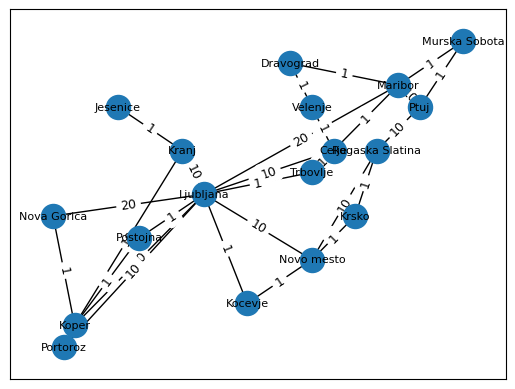

In [8]:
import networkx as nx
from matplotlib import pyplot as plt

# Load graph
G2 = nx.read_graphml('Arnes_network.graphml')
print(G2.nodes)
print(G2.edges)

position = {}
for i in G2.nodes:
    position[i] = [G2.nodes[i]['x'], G2.nodes[i]['y']]


# prepare an empty figure
plt.figure()

#Plot the graph
nx.draw_networkx(G2, pos=position, with_labels=True, font_size = 8)

edge_labels = nx.get_edge_attributes(G2, 'weight')
nx.draw_networkx_edge_labels(G2, position, edge_labels=edge_labels, font_size = 9)

In [11]:
# Node requests
requests = {'Koper':{'Ljubljana':10, 'Kranj':5, 'Murska Sobota':3}}

